# Day 6：GPT 预训练实践 — 从零训练一个小 GPT 并生成文本

> **目标**：在小规模语料上完成 GPT 预训练的完整流程——数据准备、训练循环、Loss 监控、文本生成——直观感受语言模型是如何学会「说话」的。

---

## 总体流程

```
Part 1: 数据准备
  下载 TinyShakespeare 语料 → BPE Tokenize → 创建 DataLoader

Part 2: 模型定义
  使用 Day 3 手写的 GPT（小配置）

Part 3: 训练循环
  AdamW 优化器 → Cosine LR Schedule → 训练 + 验证

Part 4: 生成与评估
  不同训练阶段的生成效果对比 → 分析 Loss 曲线
```

In [4]:
import math
import os
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


## Part 1：数据准备

使用 **TinyShakespeare** 数据集：约 1MB 的莎士比亚全集文本。虽然很小，但足以让一个小 GPT 学到基本的英语模式。

In [5]:
import urllib.request

data_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
data_path = "tinyshakespeare.txt"

if not os.path.exists(data_path):
    print("Downloading TinyShakespeare...")
    urllib.request.urlretrieve(data_url, data_path)
    print("Done!")

with open(data_path, 'r') as f:
    text = f.read()

print(f"Total characters: {len(text):,}")
print(f"First 500 chars:")
print(text[:500])

Total characters: 1,115,394
First 500 chars:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


### 1.1 Tokenization

使用 GPT-2 的 BPE tokenizer（tiktoken）来编码文本。

In [6]:
import tiktoken

enc = tiktoken.get_encoding('gpt2')

tokens = enc.encode(text)
tokens = torch.tensor(tokens, dtype=torch.long)

print(f"Total tokens: {len(tokens):,}")
print(f"Vocab size: {enc.n_vocab}")
print(f"Compression ratio: {len(text) / len(tokens):.2f} chars/token")
print(f"\nFirst 20 tokens: {tokens[:20].tolist()}")
print(f"Decoded: {enc.decode(tokens[:20].tolist())}")

Total tokens: 338,025
Vocab size: 50257
Compression ratio: 3.30 chars/token

First 20 tokens: [5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248]
Decoded: First Citizen:
Before we proceed any further, hear me speak.

All:
Spe


### 1.2 划分训练集/验证集

In [7]:
split_idx = int(len(tokens) * 0.9)
train_tokens = tokens[:split_idx]
val_tokens = tokens[split_idx:]

print(f"Train tokens: {len(train_tokens):,}")
print(f"Val tokens:   {len(val_tokens):,}")

Train tokens: 304,222
Val tokens:   33,803


### 1.3 创建 Dataset 和 DataLoader

语言模型的训练数据格式：

```
Token序列: [t_0, t_1, t_2, ..., t_n]
输入 x:    [t_0, t_1, t_2, ..., t_{n-1}]   (前 n 个 token)
标签 y:    [t_1, t_2, t_3, ..., t_n]         (后 n 个 token)
```

即 $x$ 向右移一位就是 $y$——预测下一个 token。

In [8]:
class TextDataset(Dataset):
    """从长 token 序列中随机采样固定长度的训练样本。"""
    
    def __init__(self, tokens: torch.Tensor, block_size: int):
        self.tokens = tokens
        self.block_size = block_size
    
    def __len__(self):
        return len(self.tokens) - self.block_size
    
    def __getitem__(self, idx):
        chunk = self.tokens[idx : idx + self.block_size + 1]
        x = chunk[:-1]   # 输入
        y = chunk[1:]    # 标签（右移一位）
        return x, y


# 验证数据集
block_size = 256  # 上下文窗口大小
train_dataset = TextDataset(train_tokens, block_size)
val_dataset = TextDataset(val_tokens, block_size)

x, y = train_dataset[0]
print(f"x shape: {x.shape}, y shape: {y.shape}")
print(f"x: {x[:10].tolist()}")
print(f"y: {y[:10].tolist()}")
print(f"\n验证 x 右移一位 = y: {(x[1:10] == y[:9]).all().item()}")

x shape: torch.Size([256]), y shape: torch.Size([256])
x: [5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11]
y: [22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285]

验证 x 右移一位 = y: True


In [9]:
batch_size = 32

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, 
    num_workers=0, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=0, pin_memory=True,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

# 验证一个 batch
xb, yb = next(iter(train_loader))
print(f"Batch x shape: {xb.shape}")  # (batch_size, block_size)
print(f"Batch y shape: {yb.shape}")

Train batches: 9499
Val batches:   1049
Batch x shape: torch.Size([32, 256])
Batch y shape: torch.Size([32, 256])


## Part 2：模型定义

使用 Day 3 手写的 GPT，但用更小的配置以便在 CPU/单 GPU 上快速训练。

In [10]:
from dataclasses import dataclass


@dataclass
class GPTConfig:
    vocab_size: int = 50257
    block_size: int = 256
    n_layer: int = 6
    n_head: int = 6
    n_embd: int = 384
    dropout: float = 0.1
    bias: bool = True


class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.d_head = config.n_embd // config.n_head
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.d_head))
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU(approximate='tanh')
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class GPTBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([GPTBlock(config) for _ in range(config.n_layer)]),
            ln_f=nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight
        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))
        n_params = sum(p.numel() for p in self.parameters())
        print(f"Model parameters: {n_params:,} ({n_params/1e6:.1f}M)")

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

In [11]:
config = GPTConfig()
model = GPT(config).to(device)

print(f"\nConfig: {config}")
print(f"Expected initial loss ≈ -ln(1/{config.vocab_size}) = {math.log(config.vocab_size):.2f}")

# 验证初始 loss
xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)
logits, loss = model(xb, yb)
print(f"Initial loss: {loss.item():.2f}")

Model parameters: 30,044,544 (30.0M)

Config: GPTConfig(vocab_size=50257, block_size=256, n_layer=6, n_head=6, n_embd=384, dropout=0.1, bias=True)
Expected initial loss ≈ -ln(1/50257) = 10.82
Initial loss: 10.88


## Part 3：训练循环

### 3.1 优化器和学习率调度

GPT-2/3 的训练标配：
- **AdamW**：带权重衰减的 Adam
- **Cosine Annealing**：学习率从峰值按余弦曲线衰减到最小值
- **Linear Warmup**：前几百步线性增长学习率

In [12]:
# 训练超参数
max_epochs = 10
learning_rate = 3e-4
min_lr = 3e-5
warmup_steps = 100
weight_decay = 0.1
grad_clip = 1.0

# 区分需要 weight decay 和不需要的参数
param_dict = {pn: p for pn, p in model.named_parameters() if p.requires_grad}
decay_params = [p for pn, p in param_dict.items() if p.dim() >= 2]
nodecay_params = [p for pn, p in param_dict.items() if p.dim() < 2]

optim_groups = [
    {'params': decay_params, 'weight_decay': weight_decay},
    {'params': nodecay_params, 'weight_decay': 0.0},
]

optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95))

n_decay = sum(p.numel() for p in decay_params)
n_nodecay = sum(p.numel() for p in nodecay_params)
print(f"Decayed params:   {n_decay:,} ({n_decay/1e6:.1f}M)")
print(f"No-decay params:  {n_nodecay:,} ({n_nodecay/1e3:.1f}K)")

Decayed params:   30,013,824 (30.0M)
No-decay params:  30,720 (30.7K)


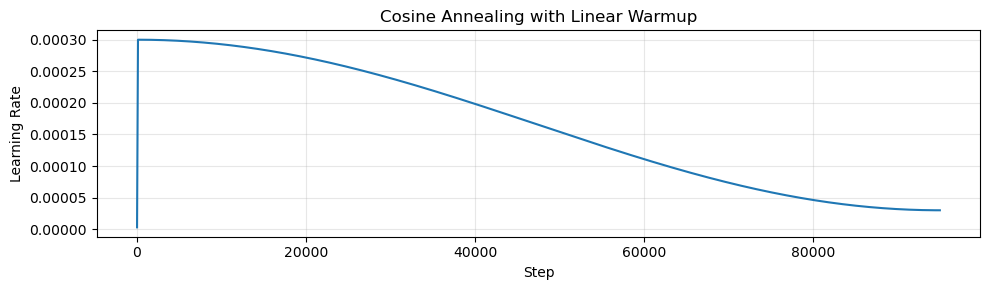

Total training steps: 94990


In [13]:
def get_lr(step: int, total_steps: int) -> float:
    """Cosine annealing with linear warmup."""
    if step < warmup_steps:
        return learning_rate * (step + 1) / warmup_steps
    if step >= total_steps:
        return min_lr
    decay_ratio = (step - warmup_steps) / (total_steps - warmup_steps)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (learning_rate - min_lr)


# 可视化学习率曲线
total_steps = max_epochs * len(train_loader)
lrs = [get_lr(s, total_steps) for s in range(total_steps)]

plt.figure(figsize=(10, 3))
plt.plot(lrs)
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Cosine Annealing with Linear Warmup')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Total training steps: {total_steps}")

### 3.2 生成函数（训练过程中定期调用）

In [14]:
@torch.no_grad()
def generate(model, prompt: str, max_new_tokens: int = 200, temperature: float = 0.8, top_k: int = 40):
    """文本生成。"""
    model.eval()
    input_ids = torch.tensor([enc.encode(prompt)], device=device)
    
    for _ in range(max_new_tokens):
        idx_cond = input_ids if input_ids.size(1) <= model.config.block_size else input_ids[:, -model.config.block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature
        
        if top_k is not None:
            topk_vals, _ = torch.topk(logits, min(top_k, logits.size(-1)), dim=-1)
            logits[logits < topk_vals[:, -1:]] = float('-inf')
        
        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        input_ids = torch.cat([input_ids, idx_next], dim=1)
    
    model.train()
    return enc.decode(input_ids[0].tolist())

### 3.3 验证函数

In [15]:
@torch.no_grad()
def evaluate(model, val_loader, max_batches=50):
    """在验证集上计算 loss 和 PPL。"""
    model.eval()
    losses = []
    for i, (xb, yb) in enumerate(val_loader):
        if i >= max_batches:
            break
        xb, yb = xb.to(device), yb.to(device)
        _, loss = model(xb, yb)
        losses.append(loss.item())
    model.train()
    avg_loss = np.mean(losses)
    ppl = math.exp(avg_loss)
    return avg_loss, ppl

### 3.4 训练！

In [ ]:
# 训练记录
train_losses = []
val_losses = []
val_ppls = []
generated_samples = []
global_step = 0

eval_interval = 200     # 每 200 步评估一次
generate_interval = 500  # 每 500 步生成一次
log_interval = 50       # 每 50 步打印一次

prompt_for_eval = "ROMEO:\n"

print("=" * 60)
print("Training starts!")
print("=" * 60)

# 训练前的初始状态
val_loss, val_ppl = evaluate(model, val_loader)
print(f"[Before training] Val Loss: {val_loss:.4f}, PPL: {val_ppl:.1f}")
sample = generate(model, prompt_for_eval, max_new_tokens=100)
generated_samples.append((0, sample))
print(f"Generated: {sample[:200]}")
print("-" * 60)

model.train()
t0 = time.time()

for epoch in range(max_epochs):
    for batch_idx, (xb, yb) in enumerate(train_loader):
        # 学习率调度
        lr = get_lr(global_step, total_steps)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        
        xb, yb = xb.to(device), yb.to(device)
        
        # 前向 + 反向
        logits, loss = model(xb, yb)
        loss.backward()
        
        # 梯度裁剪
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        
        train_losses.append(loss.item())
        global_step += 1
        
        # 打印训练状态
        if global_step % log_interval == 0:
            dt = time.time() - t0
            avg_loss = np.mean(train_losses[-log_interval:])
            print(f"  Step {global_step:5d} | Loss {avg_loss:.4f} | LR {lr:.2e} | "
                  f"Grad Norm {grad_norm:.2f} | {dt:.1f}s")
            t0 = time.time()
        
        # 验证
        if global_step % eval_interval == 0:
            val_loss, val_ppl = evaluate(model, val_loader)
            val_losses.append((global_step, val_loss))
            val_ppls.append((global_step, val_ppl))
            print(f"  >>> Val Loss: {val_loss:.4f}, PPL: {val_ppl:.1f}")
        
        # 生成示例
        if global_step % generate_interval == 0:
            sample = generate(model, prompt_for_eval, max_new_tokens=150)
            generated_samples.append((global_step, sample))
            print(f"\n  --- Generation at step {global_step} ---")
            print(f"  {sample[:300]}")
            print()
    
    # 每个 epoch 结束
    val_loss, val_ppl = evaluate(model, val_loader)
    print(f"\n[Epoch {epoch+1}/{max_epochs}] Val Loss: {val_loss:.4f}, PPL: {val_ppl:.1f}")
    print("=" * 60)

print("\nTraining complete!")

Training starts!
[Before training] Val Loss: 10.8326, PPL: 50643.7
Generated: ROMEO:
 borderlinemil 23 Hearts choppingIsraeliEveryone EDIT:] Sanchez Panasonicoded Lew prayers allowances allowances rebuilding 77uletosponsospons JasonXM going askming duplication Lauderdalereddits
------------------------------------------------------------
  Step    50 | Loss 9.3163 | LR 1.50e-04 | Grad Norm 2.14 | 3.4s
  Step   100 | Loss 6.4910 | LR 3.00e-04 | Grad Norm 0.96 | 3.1s
  Step   150 | Loss 5.3153 | LR 3.00e-04 | Grad Norm 0.77 | 3.2s
  Step   200 | Loss 4.8261 | LR 3.00e-04 | Grad Norm 0.70 | 4.1s
  >>> Val Loss: 4.5550, PPL: 95.1
  Step   250 | Loss 4.6153 | LR 3.00e-04 | Grad Norm 0.76 | 4.7s
  Step   300 | Loss 4.4380 | LR 3.00e-04 | Grad Norm 0.79 | 3.4s
  Step   350 | Loss 4.3076 | LR 3.00e-04 | Grad Norm 0.81 | 3.2s
  Step   400 | Loss 4.1758 | LR 3.00e-04 | Grad Norm 1.11 | 3.1s
  >>> Val Loss: 4.1542, PPL: 63.7
  Step   450 | Loss 4.0820 | LR 3.00e-04 | Grad Norm 1.02 | 4.1s
  Step 

## Part 4：训练分析

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train Loss
ax = axes[0]
window = 50
smoothed = np.convolve(train_losses, np.ones(window)/window, mode='valid')
ax.plot(smoothed, color='steelblue', linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Training Loss (smoothed)')
ax.grid(True, alpha=0.3)

# Val Loss
ax = axes[1]
if val_losses:
    steps, losses = zip(*val_losses)
    ax.plot(steps, losses, 'o-', color='coral', markersize=4)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Validation Loss')
ax.grid(True, alpha=0.3)

# PPL
ax = axes[2]
if val_ppls:
    steps, ppls = zip(*val_ppls)
    ax.plot(steps, ppls, 's-', color='seagreen', markersize=4)
ax.set_xlabel('Step')
ax.set_ylabel('Perplexity')
ax.set_title('Validation Perplexity')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 生成效果对比 — 不同训练阶段

In [ ]:
print("=" * 60)
print("Generation Quality Over Training")
print("=" * 60)

for step, sample in generated_samples:
    print(f"\n--- Step {step} ---")
    print(sample[:400])
    print()

### 最终生成测试

In [ ]:
test_prompts = [
    "ROMEO:\nO, she doth teach the torches",
    "KING HENRY:\nOnce more unto the breach,",
    "To be, or not to be,",
    "JULIET:\nWhat's in a name? That which we call",
]

for prompt in test_prompts:
    print(f"Prompt: {prompt}")
    print("-" * 40)
    torch.manual_seed(42)
    output = generate(model, prompt, max_new_tokens=150, temperature=0.8, top_k=40)
    print(output)
    print("=" * 60)

## Part 5：分析与思考

### 5.1 训练资源估算

| 项目 | 我们的 Baby GPT | GPT-2 Small | GPT-3 |
|------|----------------|-------------|-------|
| 参数量 | ~10M | 124M | 175B |
| 训练数据 | ~300K tokens | ~10B tokens | ~300B tokens |
| 训练时间 | ~几分钟 | ~数天 | ~数月 |
| GPU | 1× consumer | 多× V100 | 数千× A100 |
| 成本 | ~$0 | ~$50K | ~$5M+ |

### 5.2 为什么我们的模型能生成「莎士比亚风格」的文本？

1. **训练数据**：只有莎士比亚文本 → 模型只见过这种风格
2. **CLM 目标**：预测下一个 token → 学到了莎士比亚的语言模式
3. **模式匹配**：角色名后跟冒号和换行 → 学到了戏剧格式
4. **局限**：模型不「理解」莎士比亚，只是在统计上模仿

### 5.3 观察到的现象

| 训练阶段 | Loss | 生成效果 |
|---------|------|--------|
| 初始（随机） | ~10.8 | 完全随机的 token |
| 早期 | ~4-5 | 出现英文单词，但语法混乱 |
| 中期 | ~2-3 | 语法基本正确，出现角色名和对话格式 |
| 后期 | ~1.5-2 | 流畅的莎士比亚风格文本 |

### 5.4 过拟合的信号

如果训练 loss 持续下降但 val loss 开始上升，说明模型开始「背诵」训练数据而非学习通用模式。对于我们的 tiny 实验，这几乎不可避免——数据太少，模型有能力记住所有内容。

## 本日总结

### 完整流程

```
原始文本 → Tokenize → [token_ids] → 创建 (x, y) 对 → DataLoader
    ↓
GPT model (随机初始化)
    ↓
训练循环: forward → loss → backward → optimizer.step
    ↓
训练好的 GPT → 自回归生成 → 文本
```

### 工程要点

| 技巧 | 说明 |
|------|------|
| **AdamW** | 分离权重衰减和自适应学习率 |
| **Cosine LR** | 平滑衰减，收尾更好 |
| **Linear Warmup** | 避免训练初期梯度爆炸 |
| **Gradient Clipping** | 限制梯度范数，稳定训练 |
| **Weight Decay 分组** | bias 和 LN 参数不做衰减 |

### 自检清单

- [ ] 能描述 CLM 训练数据的构造方式（x 和 y 的关系）
- [ ] 理解 AdamW 与 Adam 的区别（权重衰减 vs L2 正则化）
- [ ] 理解 Cosine LR Schedule + Warmup 的设计动机
- [ ] 能解释初始 Loss ≈ ln(vocab_size) 的原因
- [ ] 观察训练过程中生成质量的变化
- [ ] 能区分过拟合和欠拟合的信号